# **Extended Toolkit for Data Extraction, Structuring, and Manipulation of Data from Bonsai Workflows in Python**
--------------------

# **Overview of this toolkit**

##### The purpose of this toolkit is to support users in creating standardised, modular workflows when working with the Bonsai ecosystem. Building on <code>harp-python</code> plus the Harp YAML schemas (e.g., `device.yml`, `soundcard.yml`), it provides higher-level utilities for extracting data exported from Bonsai experiment directories to build consistent, readable data structures for analysis.


### The core features of this toolkit include:

 1) Automate data extraction from Bonsai experiment directories and converting <code>.bin</code> files into a common <code>movement</code>-ready readable format (<code>xarrays</code> or <code>dataframes</code>)
 2) Process data from multiple peripherals and registers into convenient unified dataframes
 3) Provide utilities for handling other data formats present in Bonsai Workflows
 4) Enable the alignment of multiple different data acquistion sources 


## **Harp-Python's Built-In Tools**

Whilst the harp-python API provides users with access with access to a set of basic functions to access harp device data in Python, users will often find themselves needing to write custom code to handle common tasks, requiring significant manual user input. To show how this toolkit can be used, we will first demonstrate the general workflow for accessing harp device data using harp-python's built-in tools.

When working with Harp devices, users will find that their experimental data is organised into a hierarchical folder structure, with each device having its own subfolder containing multiple .bin files corresponding to different registers. 
Furthermore, the naming conventions for these .bin files possess a consistent pattern of <code>DeviceName_RegisterAddress_Timestamp.bin</code>, where:
- <code>DeviceName</code> is the name of the device (e.g. Behavior1)
- <code>RegisterAddress</code> is the address of the register (e.g. 32)
- <code>Timestamp</code> indicates when the data recording started (e.g. 1904-01-01T02-00-00)


In order to read just one DataFrame for one register from one device with <code>harp-python</code>, users must do the following:
1. **Create a Device Reader object**: Instantiate a device reader object using <code>harp.create_reader(***device_yaml_path***)</code>, where <code>device_yaml_path</code> is the path to the YAML file for that specific type of harp device.
2. **Manually Find the Register Name Corresponding to the Register Address**: Since harp-python requires users to specify register names (not addresses) when reading data, users must manually look up the register name corresponding to the register address they wish to read. This information can be found in the device's YAML file or documentation.
3. **Read the Data from the .bin File**: Use the device reader object to read the data from the .bin file using <code>reader.{*register_name*}.read({*file_path*})</code>, where <code>register_name</code> is the name of the register obtained in step 2, and <code>file_path</code> is the path to the .bin file.</code>

In [1]:
#======== Setup 
import harp
device_yaml_path= './device.yml'
device_register_path= './Bonsai_logs/2025-08-21T12-18-51/Behavior1/Behavior1_32_1904-01-01T02-00-00.bin'

#======= Create Device Object
reader= harp.create_reader(device_yaml_path)

#======== Load Device Schema and Register Data
reader.DigitalInputState.read(device_register_path)

,DIPort0,DIPort1,DIPort2,DI3
Time,,,,
9827.105376,False,False,True,False
9827.388576,False,False,False,False


 **The Problem:**
Whilst these tools provide a basic framework for accessing harp device data, users will often find themselves working with experiment logs containing multiple devices and multiple registers per device, as well as needing to collate data across sessions, devices, and device types. Using the above approach, users will need to manually repeat the above steps for each register of interest across multiple devices and sessions, which can be time-consuming and error-prone.

### **What This Toolkit Adds**

This toolkit exploits the one thing that is consistent across all experimental sessions: **the Bonsai output directory structure**. Device data always lives at `[device]/[register]/columns`. By defining a mapping from logical names (e.g. "Nosepoke0") to physical coordinates (device, register, localID), it provides a set of modular functions to automate repetitive tasks involved in accessing and structuring Bonsai device data. Key features of this toolkit include:

- **Automated Register Name Lookup**: Functions that automatically map register addresses to register names, eliminating the need for manual lookups.
- **Batch Data Extraction**: Utilities that allow users to extract data from multiple registers and devices in a single function call.
- **Formatting and Restructuring Data**: Functions that allow users to take dataframes extracted from individual registers and collate parts of or the whole dataframe from one or more devices into a single, unified dataframe for easier analysis.


The toolkit is organised into several key subcomponents:

| Layer | Module | What It Does |
|---|---|---|
| **Data Extraction** | `HarpExtender` | Batch-read all devices/registers into organised nested dicts |
| **Timestamps** | `Timestamps` | Collect & merge timestamps from any level of that dict |
| **Data Structuring** | `LookupArrays` | Map logical names → physical coordinates in xarray; query with `ulookup` |
| **High-Level Classes** | `MultiDevices` / `Devices` | Declarative classes that do all the above and produce xarray DataArrays in one call |
| **Non-Binary Files** | `Filetypes` | Load session files (events CSV, video CSV, visual environment) in the same pattern |
| **Multi-Modal Alignment** | `Alignment_Utils` | Sync-pulse extraction, NPX↔Bonsai time conversion, video frame timestamps, global clock |



# Insert Image png with uncorrupted filepath!

| | |
|-|-|


# **1| Setup**
---------------
This tutorial aims to walk users through a start-to-finish example workflow. For the purposes of this example, the experimental setup will consist of:
- Six nosepokes (peripherals), connected to two HARP behavior devices.
- A SoundCard device.
- Session files, including video data, experiment event logs, and session metadata.
- Neuropixels data. 
- Pose estimation data from DeepLabCut.


### Defining the rig layout

Before loading any data, users need to describe the physical wiring of their experiment — which peripherals are connected to which devices and registers. This is the **only** manual step; everything downstream is automated from it.

The key concepts are:

| Concept | What it means | Example |
|---|---|---|
| **Device** | A specific Harp device board in the experiment directory | `Behavior0`, `Behavior1` |
| **Register** | An address on a device that logs a particular I/O type | `32` (DigitalInputState) |
| **LocalID** | A column name within a register DataFrame, identifying one physical port | `DIPort0`, `DOPort1` |
| **Peripheral** | A user-chosen global name for a peripheral | `Nosepoke0` |
| **Data key** | A label for one category of data across all peripherals | `Activations`, `LED_Activations` |

Each peripheral maps to a unique `(device, register, localID)` tuple — this is the **virtual coordinate** triple that mirrors the Bonsai directory structure: `dfs_dict[device][register][localID]`.

Users define this mapping through a small set of plain Python dicts:

1. **`device_list`** — which device folders to load (e.g. `['Behavior0', 'Behavior1']`).
2. **`device_registers_dict`** — which registers to read per device.
3. **`device_list`** — the global names for every peripheral.
4. **`peripheral_localIDs`** — for each data key, the ordered list of localIDs (one per peripheral per device).
5. **`peripheral_registerIDs`** — for each localID, the register address it lives in.

In the example below the experimental rig has:
- **Two Behaviour boards** (`Behavior0`, `Behavior1`), each with three nosepokes → 6 nosepokes total.
- Each nosepoke produces **Activation** data (register 32, `DIPort0–2`) and **LED** data (register 34, `DOPort0–2`).
- A **SoundCard**, **VideoData**, and **ExperimentEvents** CSV are also present.

In [2]:
#======== User-Configurable Paths ==============================================
experiment_directory_path = './Bonsai_logs/2025-10-14T18-24-42'
harp_device_yaml_path     = './device.yml'
soundcard_yaml_path       = './soundcard.yml'
npx_sync_path             = './Bonsai_logs/sync_channel_1014.npy'

#======== Rig Layout: Devices ==================================================
# For this tutorial we use just two Behaviour boards for simplicity.
# Each board has three nosepokes connected to it → 6 nosepokes total.

device_list = ['Behavior0', 'Behavior1']

device_IDs = {
    'Behavior0': 'ID_0',
    'Behavior1': 'ID_1',
}

device_registers_dict = {
    'Behavior0': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
    'Behavior1': ['8', '32', '34', '35', '44', '49', '50', '51', '78', '92'],
}

#======== Rig Layout: Nosepoke Peripheral Definitions =============================
# Each nosepoke peripheral has a global name (e.g. "Nosepoke0") and maps to
# a specific (device, register, localID) tuple — the "virtual coordinates".
# This mapping mirrors the directory structure: dfs_dict[device][register][localID].

peripheral_list = [
    'Nosepoke0', 'Nosepoke1', 'Nosepoke2',   # → Behavior0
    'Nosepoke3', 'Nosepoke4', 'Nosepoke5',   # → Behavior1
]

# LocalIDs for each data type (column names inside the register DataFrames)
Nosepoke_Activations_localIDs     = ['DIPort0', 'DIPort1', 'DIPort2']
Nosepoke_LED_Activations_localIDs = ['DOPort0', 'DOPort1', 'DOPort2']


peripheral_localIDs = {
    'Activations':     Nosepoke_Activations_localIDs,
    'LED_Activations': Nosepoke_LED_Activations_localIDs,

}

# Which register address each localID lives in
Activations_localID_register_dict = {'DIPort0': '32', 'DIPort1': '32', 'DIPort2': '32'}
LED_Activations_localID_register_dict = {'DOPort0': '34', 'DOPort1': '34', 'DOPort2': '34'}


data_keys = {
    'Activations':     Activations_localID_register_dict,
    'LED_Activations': LED_Activations_localID_register_dict,

}

print(f"Devices: {device_list}")
print(f"peripherals: {peripheral_list}")
print(f"Data types: {list(data_keys.keys())}")

Devices: ['Behavior0', 'Behavior1']
peripherals: ['Nosepoke0', 'Nosepoke1', 'Nosepoke2', 'Nosepoke3', 'Nosepoke4', 'Nosepoke5']
Data types: ['Activations', 'LED_Activations']


In [3]:
#======== Build virtual_maps ====================================================
# One virtual_map per data type. Each maps a global channel name to its
# physical (device, register, localID) coordinates.

def build_virtual_maps(peripheral_list, device_list, peripheral_type_localIDs, data_keys):
    """Build a dict of {data_key: virtual_map} from the rig layout dicts."""
    n_ports = len(list(peripheral_type_localIDs.values())[0])  # ports per device (3)
    virtual_maps = {}

    for type_key, localIDs in peripheral_localIDs.items():
        registerID_dict = data_keys[type_key]
        vmap = {}
        for ch_idx, peripheral_name in enumerate(peripheral_list):
            dev_idx  = ch_idx // n_ports          # which device
            port_idx = ch_idx % n_ports           # which port on that device
            device   = device_list[dev_idx]
            localID  = localIDs[port_idx]
            register = registerID_dict[localID]
            vmap[peripheral_name] = {'device': device, 'register': register, 'localID': localID}
        virtual_maps[type_key] = vmap

    return virtual_maps

virtual_maps = build_virtual_maps(peripheral_list, device_list, peripheral_localIDs, data_keys)

# Inspect one of the maps
print("Activations virtual_map:")
for ch, coords in virtual_maps['Activations'].items():
    print(f"  {ch} → {coords}")

Activations virtual_map:
  Nosepoke0 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke1 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke2 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'}
  Nosepoke3 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke4 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke5 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort2'}


# **Part 2: Using MultiDevice**
-----

## 2.1| Instantiating MultiDevice

When <code>MultiDevice</code> is instantiated with both <code>experiment_directory_path</code> and <code>data_keys</code>, it automatically runs the full processing pipeline:
1. Collects DataFrames from all device folders for all registers
2. Collects and merges timestamps across devices for each data_key
3. Constructs a base <code>xr.DataArray</code> per data_key with unified channel names and a shared time axis
4. Constructs a lookup array per data_key showing the (device, register, localID) mapping
5. Updates each DataArray with the actual data values from the device DataFrames

The results are stored in:
- <code>self.data_arrays</code>: <code>{data_key: xr.DataArray}</code>
- <code>self.lookup_arrays</code>: <code>{data_key: xr.DataArray}</code>
- <code>self.lookup_virtual_coords</code>: <code>{data_key: dict}</code>

In [4]:
#======= Instantiate MultiDevice
from Refactor.MultiDevices.multidevice_mod import MultiDevice
multidevice = MultiDevice(
    virtual_maps              = virtual_maps,
    global_coord_name         = 'peripherals',
    virtual_coord_names       = ['device', 'register', 'localID'],
    data_keys                 = data_keys,
    experiment_directory_path = experiment_directory_path,
    harp_device_yaml_path     = harp_device_yaml_path,
    device_type               = 'Behavior',
    device_list               = device_list,
    device_registers_dict     = device_registers_dict,
    verbose                   = True,
)


--- Processing devices and registers ---

Processing device: Behavior0
  - Loaded register TimestampSeconds (address 8) with shape (969, 1)
  - Loaded register OutputSet (address 34) with shape (283, 14)
  - Loaded register OutputClear (address 35) with shape (294, 14)
  - Loaded register AnalogData (address 44) with shape (968908, 3)
  - Loaded register StartCameras (address 78) with shape (1, 2)
  - Loaded register Camera0Frame (address 92) with shape (57986, 1)

Processing device: Behavior1
  - Loaded register TimestampSeconds (address 8) with shape (969, 1)
  - Loaded register OutputSet (address 34) with shape (283, 14)
  - Loaded register OutputClear (address 35) with shape (294, 14)
  - Loaded register AnalogData (address 44) with shape (969009, 3)
  - Loaded register StartCameras (address 78) with shape (1, 2)
  - Loaded register Camera0Frame (address 92) with shape (57993, 1)
Skipping folder Behavior2 as it's not in device_registers_dict.
Skipping folder Behavior3 as it's not 

## 2.2| Inspecting the Outputs

The <code>data_arrays</code> dictionary contains one <code>xr.DataArray</code> per type_key. Each DataArray has:
- A <code>time</code> dimension containing the merged, sorted timestamps from all devices for that type_key
- A <code>peripherals</code> dimension containing the unified channel names
- Virtual coordinate arrays (<code>device</code>, <code>register</code>, <code>localID</code>) attached along the peripherals dimension

In [5]:
#======= Inspect data_arrays
print(f"data_arrays keys: {list(multidevice.data_arrays.keys())}\n")

for dk in multidevice.data_arrays:
    da = multidevice.data_arrays[dk]
    print(f"\n{'='*60}")
    print(f"{dk}")
    print(f"{'='*60}")
    # display(da)
    display(da.to_dataframe())

data_arrays keys: ['Activations', 'LED_Activations']


Activations


,,device,register,localID,Activations_data
Time,peripherals,,,,



LED_Activations


device register  localID  LED_Activations_data
Time         peripherals                                                   
29876.159488 Nosepoke0    Behavior0       34  DOPort0                   0.0
             Nosepoke1    Behavior0       34  DOPort1                   0.0
             Nosepoke2    Behavior0       34  DOPort2                   0.0
             Nosepoke3    Behavior1       34  DOPort0                   0.0
             Nosepoke4    Behavior1       34  DOPort1                   0.0
...                             ...      ...      ...                   ...
30839.974496 Nosepoke1    Behavior0       34  DOPort1                   0.0
             Nosepoke2    Behavior0       34  DOPort2                   0.0
             Nosepoke3    Behavior1       34  DOPort0                   0.0
             Nosepoke4    Behavior1       34  DOPort1                   0.0
             Nosepoke5    Behavior1       34  DOPort2                   0.0

[2034 rows x 4 columns]

## 2.3| Accessing the Collected DataFrames

Users can also call the individual pipeline steps directly. For example, <code>_collect_device_dfs()</code> returns the nested dictionary of DataFrames that the pipeline uses internally.

In [6]:
#======= Collect DataFrames using _collect_device_dfs
dfs_dict = multidevice._collect_device_dfs()

print(f"Top-level keys (devices): {list(dfs_dict.keys())}")
for device in dfs_dict:
    print(f"\n  {device} registers: {list(dfs_dict[device].keys())}")

#======= Display a specific register DataFrame
print(f"\n\n{'='*60}")
print(f"Behavior0, Register 32:")
print(f"{'='*60}")
display(dfs_dict['Behavior0']['32'] if '32' in dfs_dict['Behavior0'] else "Register not found")


--- Processing devices and registers ---

Processing device: Behavior0
  - Loaded register TimestampSeconds (address 8) with shape (969, 1)
  - Loaded register OutputSet (address 34) with shape (283, 14)
  - Loaded register OutputClear (address 35) with shape (294, 14)
  - Loaded register AnalogData (address 44) with shape (968908, 3)
  - Loaded register StartCameras (address 78) with shape (1, 2)
  - Loaded register Camera0Frame (address 92) with shape (57986, 1)

Processing device: Behavior1
  - Loaded register TimestampSeconds (address 8) with shape (969, 1)
  - Loaded register OutputSet (address 34) with shape (283, 14)
  - Loaded register OutputClear (address 35) with shape (294, 14)
  - Loaded register AnalogData (address 44) with shape (969009, 3)
  - Loaded register StartCameras (address 78) with shape (1, 2)
  - Loaded register Camera0Frame (address 92) with shape (57993, 1)
Skipping folder Behavior2 as it's not in device_registers_dict.
Skipping folder Behavior3 as it's not 

'Register not found'

## 2.4| Nosepoke as a Convenience Wrapper

<code>Nosepoke</code> is a thin subclass of <code>MultiDevice</code> that pre-sets nosepoke-appropriate defaults so users don't have to specify them every time:
- <code>global_coord_name = 'peripherals'</code>
- <code>virtual_coord_names = ['device', 'register', 'localID']</code>
- <code>data_keys = ['Activations', 'LEDs', 'Valves', 'Rewards']</code>
- <code>device_type = 'Behavior'</code>

Users still provide their own <code>virtual_maps</code>. The default <code>data_keys</code> can be overridden if the experiment uses different type key names.

**NB: Since <code>Nosepoke</code> delegates entirely to <code>MultiDevice</code>, the outputs are identical.**

In [7]:
from Refactor.MultiDevices.multidevice_mod import Nosepoke

#======= Instantiate Nosepoke
nosepoke = Nosepoke(
    virtual_maps              = virtual_maps,
    data_keys                 = data_keys,              # override default data_keys to match our type_key names
    experiment_directory_path = experiment_directory_path,
    harp_device_yaml_path     = harp_device_yaml_path,
    device_list               = device_list,
    device_registers_dict     = device_registers_dict,
    verbose                   = False,
    fill_value= False,
)

In [8]:
#======= Inspect Nosepoke outputs
for dk in nosepoke.data_arrays:
    da = nosepoke.data_arrays[dk]
    print(f"\n{'='*60}")
    print(f"{dk}")
    print(f"{'='*60}")
    display(da.to_dataframe().unstack('peripherals').drop(columns=['device', 'register', 'localID'], level=0))


Activations


Time



LED_Activations


LED_Activations_data                                          \
peripherals             Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                        
29876.159488                  0.0       0.0       0.0       0.0       0.0   
29879.203488                  0.0       0.0       0.0       0.0       0.0   
29879.204480                  0.0       0.0       0.0       0.0       0.0   
29881.924480                  0.0       0.0       0.0       0.0       0.0   
29887.620480                  0.0       0.0       0.0       0.0       0.0   
...                           ...       ...       ...       ...       ...   
30825.374496                  0.0       0.0       0.0       0.0       0.0   
30829.417504                  0.0       0.0       0.0       0.0       0.0   
30833.775488                  0.0       0.0       0.0       0.0       0.0   
30836.454496                  0.0       0.0       0.0       0.0       0.0   
30839.974496                  0.0       0.0       0.0       0.0       0.0   

                        
peripherals  Nosepoke5  
Time                    
29876.159488       0.0  
29879.203488       0.0  
29879.204480       0.0  
29881.924480       0.0  
29887.620480       0.0  
...                ...  
30825.374496       0.0  
30829.417504       0.0  
30833.775488       0.0  
30836.454496       0.0  
30839.974496       0.0  

[339 rows x 6 columns]

# **Part 3: Single-Device Data via `Device` Subclasses**
-----

The `Nosepoke` class (a `MultiDevice`) is for peripherals that span multiple boards and need the global→virtual mapping. For simpler devices that don't need that mapping such as SoundCards or individual camera registers, it is often more straightforward to utilise the `Device` base class or its pre-built subclasses.

These classes take the same paths and device definitions, read all specified registers, and produce a dict of `xr.DataArray`s directly from the raw DataFrames, without the need for virtual maps.

In [9]:
from Refactor.Devices.devices import Device, SoundCard

soundcard_demo = Device(experiment_directory_path=experiment_directory_path,
                        harp_device_yaml_path= './soundcard.yml',
                        device_type='SoundCard',
                        device_list=['SoundCard'],
                        device_IDs={'SoundCard': 'SoundCard0'},
                        device_registers_dict={'SoundCard': ['8', '32', '33', '35']},
                        da_type_dict={
                            'PlaySoundFreq':    ('SoundCard', '32'),
                            'StopLog':          ('SoundCard', '33'),
                            'AttenuationRight': ('SoundCard', '35'),
                        },
                        lookfor=None,
                        validate=False,
                        verbose= False,
                        )

for dfs in soundcard_demo.device_da_dict.keys():
    display(soundcard_demo.device_da_dict[dfs].to_dataframe())
 

    

,PlaySoundOrFrequency
Time,
30093.312480,880
30093.313056,880
30358.165504,880
30358.166080,880


,Stop
Time,
30093.350496,1
30358.169504,1


,AttenuationRight
Time,
30093.313504,1000
30358.166496,1000


In [10]:
#======== Camera0Frames =========================================================
from Refactor.Devices.devices import Camera0Frames
camera_frames = Camera0Frames(experiment_directory_path=experiment_directory_path)

for dfs in camera_frames.device_da_dict.keys():
    display(camera_frames.device_da_dict[dfs].to_dataframe())

,FrameAcquired
Time,
29874.791584,True
29874.808224,True
29874.824896,True
29874.841536,True
29874.858208,True
...,...
30841.103104,True
30841.119776,True
30841.136448,True


,FrameAcquired
Time,
29874.791584,True
29874.808224,True
29874.824896,True
29874.841536,True
29874.858208,True
...,...
30841.223072,True
30841.239712,True
30841.256384,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True
29874.842528,True
29874.859200,True
...,...
30841.322496,True
30841.339168,True
30841.355840,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825888,True
29874.842528,True
29874.859200,True
...,...
30841.336096,True
30841.352736,True
30841.369376,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825888,True
29874.842528,True
29874.859200,True
...,...
30841.438880,True
30841.455520,True
30841.472192,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True
29874.842528,True
29874.859200,True
...,...
30841.556416,True
30841.573088,True
30841.589760,True


# **Part 4: Non-Binary Session Files via `Filetypes`**
-----

Alongside HARP binary data, Bonsai workflows produce CSV, JSONL, and YAML files for experiment events, video metadata, visual environments, and session settings.

The `FileTypeData` base class and its subclasses (`ExperimentEvents`, `VideoData`, `VisualEnvironment`, etc.) auto-locate and load these files from the experiment directory using the same device_type prefix pattern. Each produces a `.df` attribute containing the loaded DataFrame.

In [11]:
#======== ExperimentEvents ======================================================
# Loads the ExperimentEvents CSV. Automatically renames 'Value' → 'Event', and sets the index to 'Time'.

from Refactor.Filetypes.filetypes import ExperimentEvents
events = ExperimentEvents(experiment_directory_path=experiment_directory_path)
print(f"ExperimentEvents: {events.df.shape[0]} events")
display(events.df.head(10))

ExperimentEvents: 26 events


,Event
Time,
29872.322976,Workflow started
29874.790976,Request camera start
29875.153984,Start Sync Pulse
29875.629984,Start trial logic
29875.894976,Trial start
29875.894976,Rotating nosepoke
29875.924992,Start mismatch rotations
29878.962976,Performing outer rotations
29888.980992,Target zone available (X Y : 395 290 - Radius ...


In [12]:
#======== VideoData =============================================================
from Refactor.Filetypes.filetypes import VideoData
video_data = VideoData(experiment_directory_path=experiment_directory_path, file_type='csv')
print(f"VideoData: {video_data.df.shape[0]} rows")
display(video_data.df.head())

VideoData: 57999 rows


,FrameID,Timestamp
Time,,
29874.792576,489850,29849558403592
29874.809216,489851,29849575068920
29874.825856,489852,29849591735704
29874.842528,489853,29849608401160
29874.859200,489854,29849625063616


In [13]:
#======== VisualEnvironment ====================================================
from Refactor.Filetypes.filetypes import VisualEnvironment
vis_env = VisualEnvironment(experiment_directory_path=experiment_directory_path, file_type='csv')
print(f"\nVisualEnvironment: {vis_env.df.shape[0]} rows, columns: {list(vis_env.df.columns)}")
display(vis_env.df.head())


VisualEnvironment: 4 rows, columns: ['Value', 'Landmark', 'Landmark_Proximal', 'Gratings', 'Firefly']


,Value,Landmark,Landmark_Proximal,Gratings,Firefly
Time,,,,,
29875.880000,Visual environment OFF,None,None,None,None
29878.962976,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF
30113.132992,Visual environment OFF,None,None,None,None
30116.152000,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF


## Part 5 — LookupArrays: the indexing engine

Every `MultiDevice` internally builds two xarray objects per data key:

| Object | What it stores | Shape |
|--------|---------------|-------|
| **Data array** | The actual sensor values (e.g. activation booleans) | `(time, global_peripherals)` |
| **Lookup array** | A boolean matrix that maps each *global* peripheral → its *virtual* coordinates (device, register, localID) | `(global_peripherals, virtual_coord_levels)` |

The function `ulookup(lookup_array, **kwargs)` queries the lookup array to find
which global indices match a set of virtual coordinates — so you never need to
remember raw column numbers.

Below we show the standalone functions that `Nosepoke` calls under the hood.

In [14]:
# ---- Retrieve the lookup array that Nosepoke already built ----
from Refactor.LookupArrays.Lookup_Arrays_mod import ulookup

activations_lookup = nosepoke.lookup_arrays['Activations']

print("Lookup array shape:", activations_lookup.shape)
print("Dims:", activations_lookup.dims)
print("Coords:")
for c in activations_lookup.coords:
    print(f"  {c}: {activations_lookup.coords[c].values}")
print()

# ---- ulookup: query by virtual coordinates ----
# "Which global peripheral indices correspond to Behavior0, register 32?"
matched_indices = ulookup(lookup_array=activations_lookup, global_coord_name= 'peripherals', device='Behavior0', register='32')
print(f"ulookup(device='Behavior0', register='32') → global indices: {matched_indices}")

# "All peripherals on Behavior1?"
matched_b1 = ulookup(lookup_array=activations_lookup, global_coord_name= 'peripherals', device='Behavior1')
print(f"ulookup(device='Behavior1')                → global indices: {matched_b1}")

Lookup array shape: (6,)
Dims: ('peripherals',)
Coords:
  peripherals: ['Nosepoke0' 'Nosepoke1' 'Nosepoke2' 'Nosepoke3' 'Nosepoke4' 'Nosepoke5']
  device: ['Behavior0' 'Behavior0' 'Behavior0' 'Behavior1' 'Behavior1' 'Behavior1']
  register: ['32' '32' '32' '32' '32' '32']
  localID: ['DIPort0' 'DIPort1' 'DIPort2' 'DIPort0' 'DIPort1' 'DIPort2']

ulookup(device='Behavior0', register='32') → global indices: ['Nosepoke0', 'Nosepoke1', 'Nosepoke2']
ulookup(device='Behavior1')                → global indices: ['Nosepoke3', 'Nosepoke4', 'Nosepoke5']


## Part 6 — Alignment Utils: synchronising Bonsai and Neuropixel clocks

### Why alignment is needed

Bonsai/Harp and Neuropixel run on **independent clocks** that drift over time.
To combine behavioural events (Harp timestamps) with neural data (NPX sample
indices) we need a shared time reference.

**How it works:**

1. A **TTL square-wave pulse train** is generated and recorded on both systems
   simultaneously — one copy on a Harp Behavior board (digital IO), one on an
   NPX sync channel.
2. `DigitalSyncPulse` extracts the Bonsai-side pulse start/end times (in
   seconds) from DO1 rise/fall registers (34 & 35) of the sync device.
3. `Npx_SyncPulse` extracts the NPX-side pulse durations from the raw `.npy`
   recording (in sample units, converted via `npx_frequency`).
4. `get_aligned_pulse_dfs` trims both pulse trains to the same count and
   normalises t = 0 to the first pulse.
5. `get_npx_to_bonsai_time_conversion` computes a single linear conversion
   ratio: $r = \frac{\Delta t_{\text{NPX}}}{\Delta t_{\text{Bonsai}}}$. It
   also produces error diagnostics (scatter + histogram) so you can verify that
   drift is within tolerance.
6. `convert_npx_to_bonsai_time` applies this ratio to any NPX DataFrame,
   Series, or array to express it in Bonsai seconds.

In [15]:
#==== 1| Extract Bonsai-side sync pulses ==================================================
from Refactor.Alignment_Utils.alignment_utils import DigitalSyncPulse

sync_pulses = DigitalSyncPulse(
    experiment_directory_path= experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    Sync_device=['Behavior3'],
    device_list=['Behavior3'],
    device_IDs={'Behavior3': 'ID_3'},
    device_registers_dict_str=['34', '35'],
    min_duration=0.0,
    align_to_zero=True,
    verbose=False,
)

print(f"Bonsai sync pulses: {len(sync_pulses.SyncPulseTimes)} detected")
print(f"Initial start offset (original timebase): {sync_pulses.initial_start_offset:.4f} s")
display(sync_pulses.SyncPulseTimes)

Bonsai sync pulses: 282 detected
Initial start offset (original timebase): 29876.1605 s


,Start,End,Duration
Pulse,,,
1,0.000000,0.762016,0.762016
2,3.044000,3.580000,0.536000
3,5.765024,8.516000,2.750976
4,11.461024,13.534016,2.072992
5,15.202016,17.903008,2.700992
...,...,...,...
278,944.649024,947.646016,2.996992
279,949.214016,952.097024,2.883008
280,953.257024,955.078016,1.820992


In [16]:
# ==== 2| Extract NPX-side sync pulses ==================================================
from Refactor.Alignment_Utils.alignment_utils import Npx_SyncPulse
npx_sync = Npx_SyncPulse(
    npx_path       = npx_sync_path,
    npx_frequency  = 1,          # 30 kHz NPX sampling rate
    align_to_zero  = False,
    df_active_only= True,
    verbose        = False,
)

print(f"NPX sync pulses: {len(npx_sync.npx_pulse_durations)} detected")
display(npx_sync.npx_pulse_durations.head())

NPX sync pulses: 165 detected


,Start,End,Duration,State
Pulse,,,,
0,341852.0,364711.0,22859.0,100
1,433171.0,449250.0,16079.0,100
2,514802.0,597330.0,82528.0,100
3,685682.0,747870.0,62188.0,100
4,797911.0,878940.0,81029.0,100


### Step 3 — Align & convert

`get_npx_to_bonsai_time_conversion` internally calls `get_aligned_pulse_dfs`
to trim both pulse trains to the same count and normalise t = 0, then computes
the conversion ratio $r$.  Passing `visualisation=True` shows the overlaid
pulse trains; `error_visualisation_tools=True` adds per-pulse error scatter
plots and histograms so you can verify sub-millisecond alignment.

Using 165 pulses. Sync start range: 0.0 -> 569.197024000001
Using 165 pulses. Npx start range: 0.0 -> 17075877.0
Computed NPX to Bonsai ratio (NPX_time/Bonsai_time): 29999.940758650155.
Convert using 1 / 29999.940758650155 to get Bonsai_time from NPX_time.

NPX time range: 0.0 to 17075877.0 units.
Total duration: 17075877.0 units for 165 pulses.

Bonsai time range: 0.0 to 569.197024000001 seconds.
Total duration: 569.197024000001 seconds for 165 pulses.

Converted NPX pulse times to Bonsai times:
          Start         End  Duration  State
0      0.000000    0.761968  0.761968    100
1      3.043973    3.579940  0.535968    100
2      5.765011    8.515950  2.750939    100
3     11.461023   13.533960  2.072937    100
4     15.201997   17.902969  2.700972    100
..          ...         ...       ...    ...
160  554.711029  555.249996  0.538968    100
161  556.989033  558.196002  1.206969    100
162  560.927008  561.659976  0.732968    100
163  563.900014  566.778986  2.878972    100
164

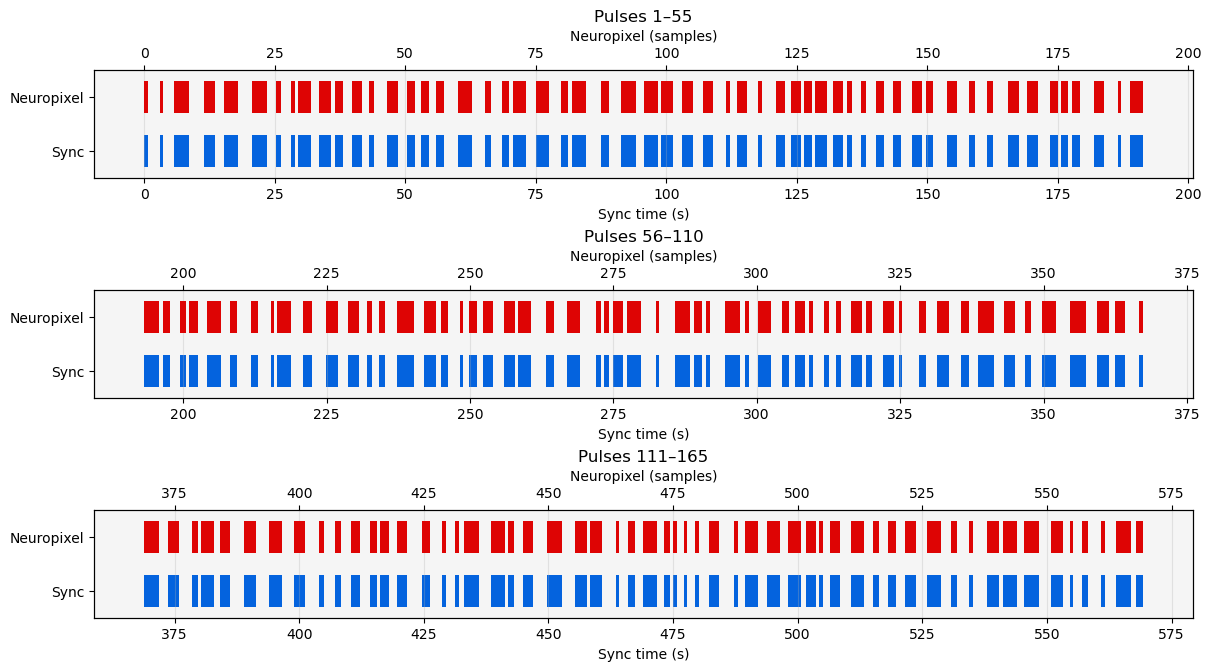

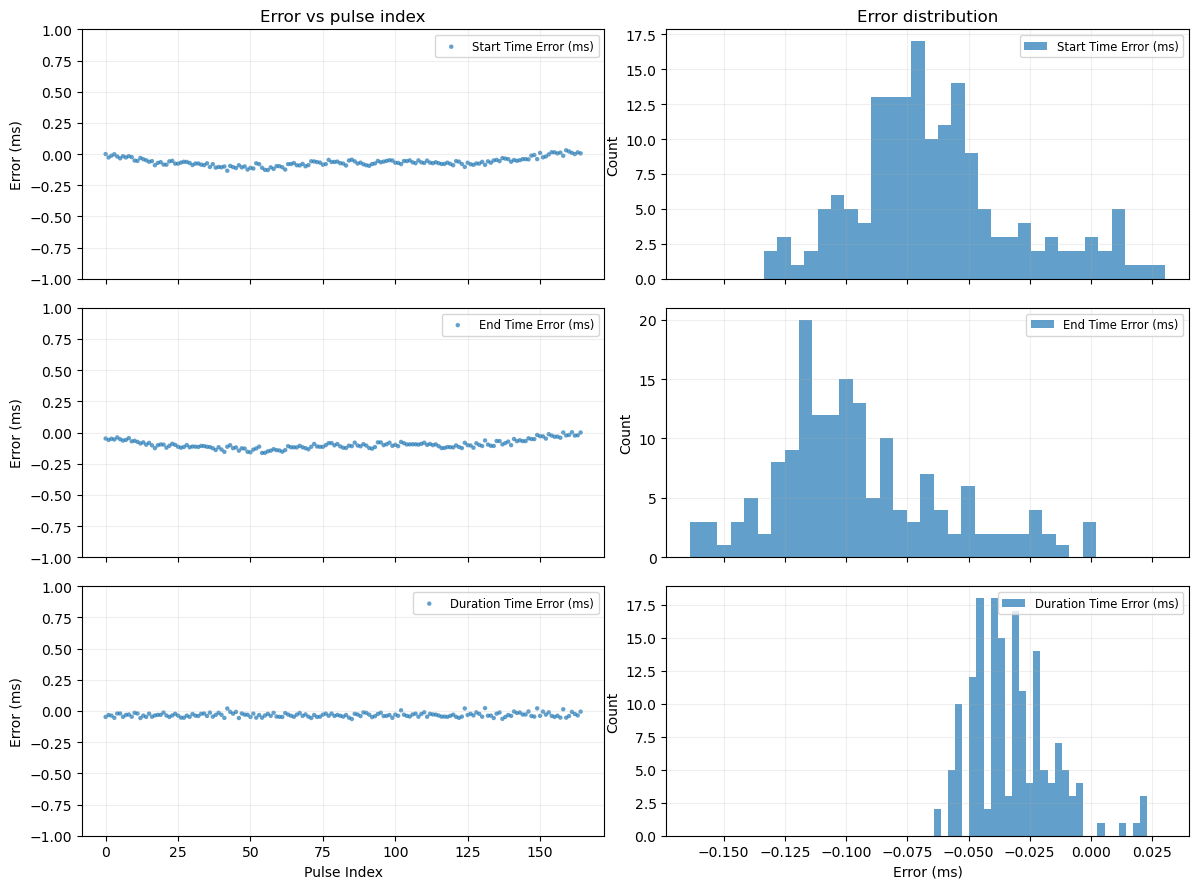


Conversion ratio (NPX_time / Bonsai_time): 29999.9407586502
To go from NPX → Bonsai:  bonsai_t = (npx_t - npx_start) / ratio + bonsai_start


In [17]:
#==== 3| Compute Conversion Ratio with Diagnostics  ==================================================
from Refactor.Alignment_Utils.alignment_utils import get_npx_to_bonsai_time_conversion
aligned_npx_converted, npx_conversion_ratio = get_npx_to_bonsai_time_conversion(
    sync_df                  = sync_pulses.SyncPulseTimes,
    npx_df                   = npx_sync.npx_pulse_durations,
    visualisation            = True,      # overlaid pulse trains
    error_visualisation_tools = True,     # per-pulse error scatter + histograms
    verbose                  = True,
)

print(f"\nConversion ratio (NPX_time / Bonsai_time): {npx_conversion_ratio:.10f}")
print(f"To go from NPX → Bonsai:  bonsai_t = (npx_t - npx_start) / ratio + bonsai_start")

In [18]:
#==== 4| Convert arbitrary NPX data → Bonsai time ==================================================
from Refactor.Alignment_Utils.alignment_utils import convert_npx_to_bonsai_time
npx_pulse_df_in_bonsai_time = convert_npx_to_bonsai_time(
    npx_data       = npx_sync.npx_pulse_durations,
    npx_sync_pulse = npx_sync,
    sync_pulses    = sync_pulses,
    verbose        = False,
)

print("NPX pulse durations converted to Bonsai seconds:")
display(npx_pulse_df_in_bonsai_time.head())

NPX pulse durations converted to Bonsai seconds:


,Start,End,Duration,State
Pulse,,,,
0,0.000000,0.761968,0.761968,100
1,3.043973,3.579940,0.535968,100
2,5.765011,8.515950,2.750939,100
3,11.461023,13.533960,2.072937,100
4,15.201997,17.902969,2.700972,100


## Part 7 — Video timestamps & the global clock

### Video timestamps

`get_video_timestamps` uses `sleap_io` to read the video frame count, then
auto-matches it against the Camera0Frames harp data to assign a Bonsai-time
timestamp to every frame.  This requires `sleap_io` to be installed and a
video file on disk.


### Global clock

`create_global_clock` builds a uniformly-spaced time axis (e.g. at 1 ms
resolution) that serves as the shared index for all data streams.
`index_map_util` then maps each stream's irregular timestamps onto the
nearest global-clock bin, producing a `(N × 5)` matrix of
`[global_idx, stream_idx, global_time, stream_time, Δt]`.

In [20]:
#==== Video Timestamps 
import os
from Refactor.Alignment_Utils.alignment_utils import get_video_timestamps
video_file_path = os.path.join(experiment_directory_path,
                               'VideoData', 'VideoData_1904-01-01T08-00-00.avi')

frame_times_da = get_video_timestamps(
        experiment_directory_path = experiment_directory_path,
        video_path               = video_file_path,
        auto_match_device        = True,
        harp_device_yaml_path    = harp_device_yaml_path,
        verbose                  = True,
    )
print(f"\nVideo frame timestamps: {frame_times_da.shape} DataArray")
display(frame_times_da[:5])


Video frame count: 57999

--- Processing devices and registers ---

Processing device: Behavior0
  - Loaded register Camera0Frame (address 92) with shape (57986, 1)

Processing device: Behavior1
  - Loaded register Camera0Frame (address 92) with shape (57993, 1)

Processing device: Behavior2
  - Loaded register Camera0Frame (address 92) with shape (57999, 1)

Processing device: Behavior3
  - Loaded register Camera0Frame (address 92) with shape (58000, 1)

Processing device: Behavior4
  - Loaded register Camera0Frame (address 92) with shape (58006, 1)

Processing device: Behavior5
  - Loaded register Camera0Frame (address 92) with shape (58013, 1)
Built DataArray 'Behavior0_Camera0Frame' from Behavior0[92]
Built DataArray 'Behavior1_Camera0Frame' from Behavior1[92]
Built DataArray 'Behavior2_Camera0Frame' from Behavior2[92]
Built DataArray 'Behavior3_Camera0Frame' from Behavior3[92]
Built DataArray 'Behavior4_Camera0Frame' from Behavior4[92]
Built DataArray 'Behavior5_Camera0Frame' from

<xarray.DataArray 'timestamp' (frame: 5)> Size: 40B
array([29874.792576, 29874.809216, 29874.825856, 29874.842528,
       29874.8592  ])
Coordinates:
  * frame    (frame) int64 40B 0 1 2 3 4

In [25]:
#===== Create a global clock and map Activations stream onto it ==================================================
from Refactor.Alignment_Utils.alignment_utils import create_global_clock, index_map_util
import numpy as np
bonsai_start = sync_pulses.initial_start_offset   # original session start
bonsai_end   = bonsai_start + sync_pulses.SyncPulseTimes['End'].iloc[-1]
print(f"Bonsai session start: {bonsai_start:.3f} s, end: {bonsai_end:.3f} s, duration: {bonsai_end - bonsai_start:.3f} s")
global_clock = create_global_clock(
    start_time         = 0.0,
    end_time           = bonsai_end - bonsai_start,  # relative time
    timestep_interval  = 1,                      # 1 ms bins
    include_end_time   = True,
    verbose            = True,
)

# Map the Activations xarray time axis onto the global clock.
activations_da = nosepoke.data_arrays['Activations']
stream_times   = activations_da.coords['Time'].values - bonsai_start  # relative

times_matrix, index_matrix, full_matrix = index_map_util(
    global_clock_times = global_clock,
    stream_times       = stream_times,
    match_type         = 'Before',
)

print(f"\nGlobal clock: {len(global_clock)} bins ({global_clock[0]:.3f} → {global_clock[-1]:.3f} s)")
print(f"Activations stream: {len(stream_times)} samples")
print(f"full_matrix shape: {full_matrix.shape}  (cols: global_idx, stream_idx, global_t, stream_t, Δt)")
print(f"Max |Δt| = {np.nanmax(np.abs(full_matrix[:, 4])):.6f} s")

Bonsai session start: 29876.160 s, end: 30838.088 s, duration: 961.928 s
Including end_time: 961.9279999999999 in global clock times. Final time array length: 963, with final timestep size: 0.9279999999998836
Created global clock times from 0.0 to 961.9279999999999 with timestep interval 1. Total timesteps: 963


IndexError: index 0 is out of bounds for axis 0 with size 0

## Part 8 — Unified results dictionary

The goal of the whole pipeline is a single `results` dictionary where every
data stream — Bonsai/Harp, Neuropixel, Filetypes, and video — lives in a
common xarray-compatible format with aligned time references.

Below we assemble `results` from the objects created in Parts 2–7.

In [ ]:
# ---- Assemble the unified results dict ----

results = {}

# --- Bonsai / Harp: MultiDevice data arrays + lookup arrays ---
for dk in nosepoke.data_arrays:
    results[f'nosepoke_{dk}'] = {
        'data':   nosepoke.data_arrays[dk],            # xr.DataArray (Time × peripherals)
        'lookup': nosepoke.lookup_arrays[dk][0],       # xr.DataArray (peripherals × virtual coords)
    }

# --- Bonsai / Harp: Single-device data arrays ---
for dk, da in soundcard_demo.device_da_dict.items():
    results[f'soundcard_{dk}'] = {'data': da}

for dk, da in camera_frames.device_da_dict.items():
    results[f'camera_{dk}'] = {'data': da}

# --- Filetypes ---
results['experiment_events'] = {'data': events.df}
results['video_data']        = {'data': video_data.df}
results['visual_environment'] = {'data': vis_env.df}

# --- Neuropixel alignment ---
results['sync_alignment'] = {
    'bonsai_sync_pulses': sync_pulses.SyncPulseTimes,
    'npx_sync_pulses':    npx_sync.npx_pulse_durations,
    'npx_converted':      aligned_npx_converted,
    'conversion_ratio':   npx_conversion_ratio,
    'bonsai_start_offset': sync_pulses.initial_start_offset,
}

# --- Global clock & index map ---
results['global_clock'] = {
    'times':       global_clock,
    'index_map':   full_matrix,           # (N × 5) for Activations stream
    'timestep_ms': 1.0,
}

# --- Video timestamps (if available) ---
if frame_times_da is not None:
    results['video_timestamps'] = {'data': frame_times_da}

print(f"Results dict assembled — {len(results)} entries:")
for k, v in results.items():
    if isinstance(v, dict) and 'data' in v:
        d = v['data']
        shape = getattr(d, 'shape', getattr(d, 'dims', len(d)))
        print(f"  {k:30s}  shape={shape}")
    else:
        print(f"  {k:30s}  keys={list(v.keys())}")

Results dict assembled — 17 entries:
  nosepoke_Activations            shape=(14, 6)
  nosepoke_LED_Activations        shape=(521, 6)
  soundcard_PlaySoundFreq         shape=FrozenMappingWarningOnValuesAccess({'Time': 6})
  soundcard_StopLog               shape=FrozenMappingWarningOnValuesAccess({'Time': 3})
  soundcard_AttenuationRight      shape=FrozenMappingWarningOnValuesAccess({'Time': 1})
  camera_Behavior0_Camera0Frame   shape=FrozenMappingWarningOnValuesAccess({'Time': 78682})
  camera_Behavior1_Camera0Frame   shape=FrozenMappingWarningOnValuesAccess({'Time': 78688})
  camera_Behavior2_Camera0Frame   shape=FrozenMappingWarningOnValuesAccess({'Time': 78695})
  camera_Behavior3_Camera0Frame   shape=FrozenMappingWarningOnValuesAccess({'Time': 78702})
  camera_Behavior4_Camera0Frame   shape=FrozenMappingWarningOnValuesAccess({'Time': 78708})
  camera_Behavior5_Camera0Frame   shape=FrozenMappingWarningOnValuesAccess({'Time': 78715})
  experiment_events               shape=(47, 1)
  